Best Tour: [-2  0  0  0  5 16  5 -2  9  4]
Best Distance: 2.541294293790601


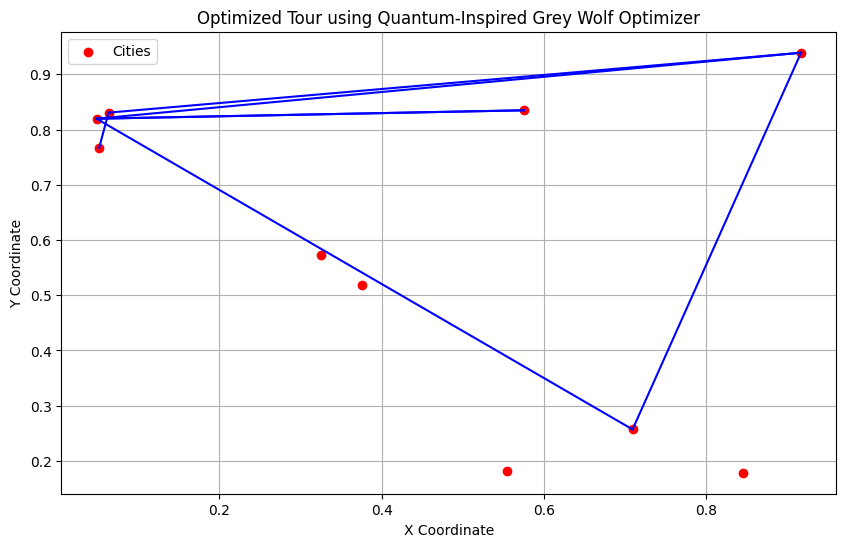

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations

# Define the coordinates
x = [0.554269387, 0.376125156, 0.051884288, 0.04856034, 0.574909957,
     0.845223483, 0.916561361, 0.063353565, 0.70899005, 0.324740555]

y = [0.180978238, 0.518855489, 0.767196762, 0.819692827, 0.834901769,
     0.178691015, 0.939163958, 0.830678509, 0.257090618, 0.573308569]

n_cities = 10
n_vehicles = 1
max_iterations = 100
population_size = 50

# Function to calculate the total distance of a tour
def calculate_distance(tour):
    distance = 0.0
    for i in range(len(tour) - 1):
        # Ensure tour[i] and tour[i+1] are valid indices
        idx1 = tour[i] % len(x)  # Wrap around if index is out of bounds
        idx2 = tour[i + 1] % len(x)  # Wrap around if index is out of bounds
        distance += np.sqrt((x[idx1] - x[idx2]) ** 2 + (y[idx1] - y[idx2]) ** 2)
    distance += np.sqrt((x[tour[-1] % len(x)] - x[tour[0] % len(x)]) ** 2 + (y[tour[-1] % len(x)] - y[tour[0] % len(x)]) ** 2)  # Return to start
    return distance

# Quantum-Inspired Grey Wolf Optimizer
class QIGWO:
    def __init__(self, population_size, max_iterations):
        self.population_size = population_size
        self.max_iterations = max_iterations
        self.wolves = [np.random.permutation(n_cities) for _ in range(population_size)]
        self.alpha = None
        self.beta = None
        self.delta = None
        self.alpha_score = float('inf')
        self.beta_score = float('inf')
        self.delta_score = float('inf')

    def optimize(self):
        for iteration in range(self.max_iterations):
            for wolf in self.wolves:
                score = calculate_distance(wolf)
                if score < self.alpha_score:
                    self.delta_score = self.beta_score
                    self.delta = self.beta
                    self.beta_score = self.alpha_score
                    self.beta = self.alpha
                    self.alpha_score = score
                    self.alpha = wolf
                elif score < self.beta_score:
                    self.delta_score = self.beta_score
                    self.delta = self.beta
                    self.beta_score = score
                    self.beta = wolf
                elif score < self.delta_score:
                    self.delta_score = score
                    self.delta = wolf

            a = 2 - iteration * (2 / self.max_iterations)  # Decrease a from 2 to 0

            for i in range(self.population_size):
                for j in range(len(self.wolves[i])):
                    r1 = np.random.rand()
                    r2 = np.random.rand()
                    A = 2 * a * r1 - a
                    C = 2 * r2
                    D_alpha = np.abs(C * self.alpha[j] - self.wolves[i][j])
                    X1 = self.alpha[j] - A * D_alpha

                    r1 = np.random.rand()
                    A = 2 * a * r1 - a
                    D_beta = np.abs(C * self.beta[j] - self.wolves[i][j])
                    X2 = self.beta[j] - A * D_beta

                    r1 = np.random.rand()
                    A = 2 * a * r1 - a
                    D_delta = np.abs(C * self.delta[j] - self.wolves[i][j])
                    X3 = self.delta[j] - A * D_delta

                    self.wolves[i][j] = (X1 + X2 + X3) / 3

            # Ensure the wolves are valid permutations
            for i in range(self.population_size):
                self.wolves[i] = np.unique(np.round(self.wolves[i]).astype(int))[:n_cities]
                if len(self.wolves[i]) < n_cities:
                  self.wolves[i] = np.concatenate((self.wolves[i], np.random.choice(range(n_cities), n_cities - len(self.wolves[i]), replace=False)))

        return self.alpha, self.alpha_score

# Plotting function
def plot_tour(tour, title):
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color='red', label='Cities')

    # Ensure the tour covers all cities and wraps around
    extended_tour = tour + [tour[0]]  # Connect back to the starting city

    for i in range(len(extended_tour) - 1):
        # Ensure idx1 and idx2 are within the valid range
        idx1 = extended_tour[i] % len(x)
        idx2 = extended_tour[i + 1] % len(x)
        plt.plot([x[idx1], x[idx2]], [y[idx1], y[idx2]], color='blue')

    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.legend()
    plt.grid()
    plt.show()

# Main execution
if __name__ == "__main__":
    qigwo = QIGWO(population_size, max_iterations)
    best_tour, best_distance = qigwo.optimize()

    print("Best Tour:", best_tour)
    print("Best Distance:", best_distance)

    # Plot the initial points and the optimized tour
    plot_tour(best_tour, "Optimized Tour using Quantum-Inspired Grey Wolf Optimizer")

Best Tour: [0 1 2 3 7 9 6 4 8 5]
Best Distance: 3.3225261426646497


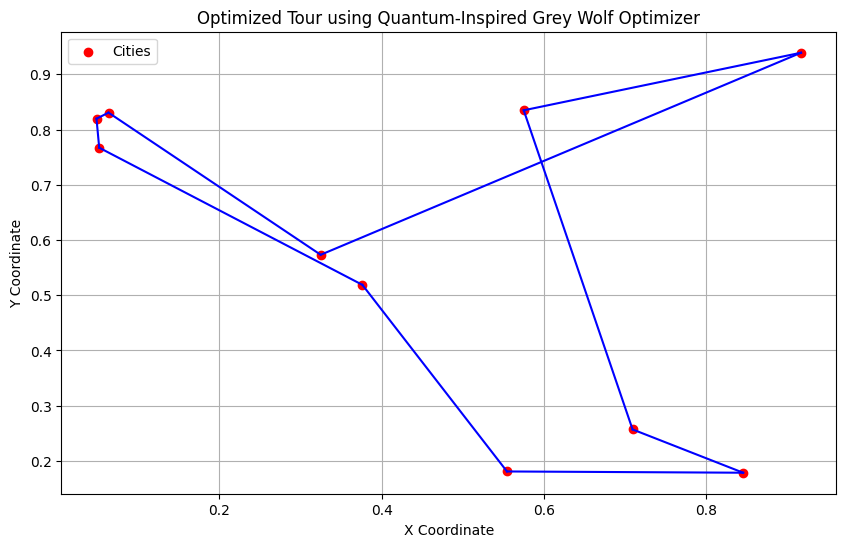

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the coordinates
x = [0.554269387, 0.376125156, 0.051884288, 0.04856034, 0.574909957,
     0.845223483, 0.916561361, 0.063353565, 0.70899005, 0.324740555]

y = [0.180978238, 0.518855489, 0.767196762, 0.819692827, 0.834901769,
     0.178691015, 0.939163958, 0.830678509, 0.257090618, 0.573308569]

n_cities = 10
max_iterations = 100
population_size = 50

# Function to calculate the total distance of a tour
def calculate_distance(tour):
    distance = 0.0
    for i in range(len(tour) - 1):
        distance += np.sqrt((x[tour[i]] - x[tour[i + 1]]) ** 2 + (y[tour[i]] - y[tour[i + 1]]) ** 2)
    distance += np.sqrt((x[tour[-1]] - x[tour[0]]) ** 2 + (y[tour[-1]] - y[tour[0]]) ** 2)  # Return to start
    return distance

# Quantum-Inspired Grey Wolf Optimizer
class QIGWO:
    def __init__(self, population_size, max_iterations):
        self.population_size = population_size
        self.max_iterations = max_iterations
        self.wolves = [np.random.permutation(n_cities) for _ in range(population_size)]
        self.alpha = self.wolves[0]  # Initialize alpha to the first wolf
        self.beta = None
        self.delta = None
        self.alpha_score = float('inf')
        self.beta_score = float('inf')
        self.delta_score = float('inf')

    def optimize(self):
        for iteration in range(self.max_iterations):
            for wolf in self.wolves:
                score = calculate_distance(wolf)
                self.update_leaders(wolf, score)

            a = 2 - iteration * (2 / self.max_iterations)  # Decrease a from 2 to 0

            for i in range(self.population_size):
                self.update_wolf_position(i, a)

        return self.alpha, self.alpha_score

    def update_leaders(self, wolf, score):
        if score < self.alpha_score:
            self.delta_score = self.beta_score
            self.delta = self.beta.copy() if self.beta is not None else None
            self.beta_score = self.alpha_score
            self.beta = self.alpha.copy() if self.alpha is not None else None
            self.alpha_score = score
            self.alpha = wolf.copy()
        elif score < self.beta_score:
            self.delta_score = self.beta_score
            self.delta = self.beta.copy() if self.beta is not None else None
            self.beta_score = score
            self.beta = wolf.copy()
        elif score < self.delta_score:
            self.delta_score = score
            self.delta = wolf.copy()

    def update_wolf_position(self, index, a):
        # Update positions based on alpha, beta, delta
        for j in range(len(self.wolves[index])):
            r1 = np.random.rand()
            r2 = np.random.rand()
            A = 2 * a * r1 - a
            C = 2 * r2
            D_alpha = np.abs(C * self.alpha[j] - self.wolves[index][j])
            X1 = self.alpha[j] - A * D_alpha

            r1 = np.random.rand()
            A = 2 * a * r1 - a
            D_beta = np.abs(C * self.beta[j] - self.wolves[index][j])
            X2 = self.beta[j] - A * D_beta

            r1 = np.random.rand()
            A = 2 * a * r1 - a
            D_delta = np.abs(C * self.delta[j] - self.wolves[index][j])
            X3 = self.delta[j] - A * D_delta

            # Update the wolf's position
            self.wolves[index][j] = (X1 + X2 + X3) / 3

        # Ensure valid permutation
        self.wolves[index] = self.ensure_valid_permutation(self.wolves[index])

    def ensure_valid_permutation(self, wolf):
        # Round and convert to integers
        wolf = np.round(wolf).astype(int) % n_cities  # Ensure indices are within bounds
        unique_cities = np.unique(wolf)
        if len(unique_cities) < n_cities:
            missing_cities = np.setdiff1d(np.arange(n_cities), unique_cities)
            wolf = np.concatenate((unique_cities, np.random.choice(missing_cities, n_cities - len(unique_cities), replace=False)))
        return wolf[:n_cities]  # Ensure the length is exactly n_cities

# Plotting function
def plot_tour(tour, title):
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color='red', label='Cities')
    for i in range(len(tour)):
        plt.plot([x[tour[i]], x[tour[(i + 1) % len(tour)]]], [y[tour[i]], y[tour[(i + 1) % len(tour)]]], color='blue')
    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.legend()
    plt.grid()
    plt.show()

# Main execution
if __name__ == "__main__":
    qigwo = QIGWO(population_size, max_iterations)
    best_tour, best_distance = qigwo.optimize()

    print("Best Tour:", best_tour)
    print("Best Distance:", best_distance)

    # Plot the optimized tour
    plot_tour(best_tour, "Optimized Tour using Quantum-Inspired Grey Wolf Optimizer")

In [ ]:
!pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.5/108.5 kB 10.7 MB/s eta 0:00:00


In [ ]:
pip install qiskit --upgrade

In [ ]:
import qiskit
print("Qiskit version:", qiskit.__version__)

Qiskit version: 1.3.1


In [ ]:
from qiskit import QuantumCircuit, transpile
print("Qiskit components are available.")

Qiskit components are available.


In [ ]:
pip install qiskit_aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 85.5 MB/s eta 0:00:00


In [ ]:
!pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136816 sha256=e8edb4c21d8c351dd22e77b6d8cc03b4e88f8ce8150a069870a9597a10ba49b9
  Stored in directory: /root/.cache/pip/wheels/b1/7a/33/9fdd892f784ed4afda62b685ae3703adf4c91aa0f524c28f03
Successfully built pylatexenc


Best Tour: [0 1 4 5 7 8 9 6 2 3]
Best Distance: 9.263321603358854e-05


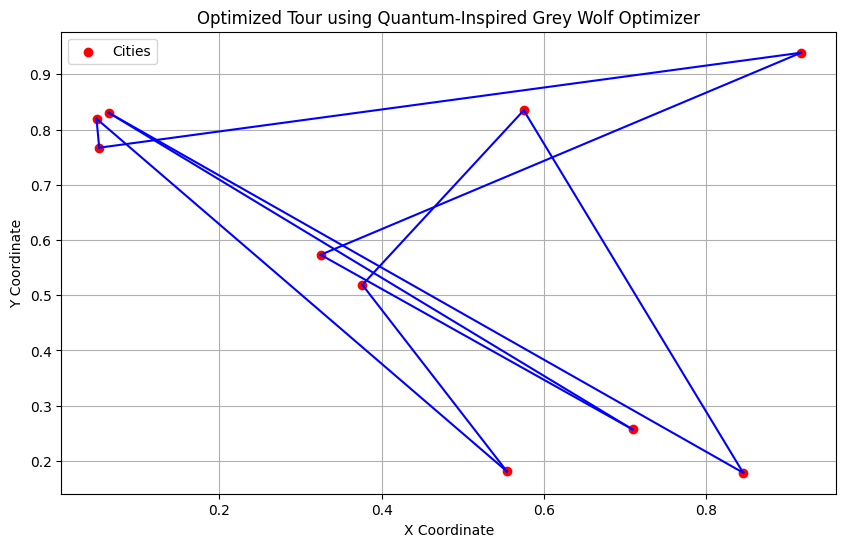

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator, Aer

# Define the coordinates
x = [0.554269387, 0.376125156, 0.051884288, 0.04856034, 0.574909957,
     0.845223483, 0.916561361, 0.063353565, 0.70899005, 0.324740555]

y = [0.180978238, 0.518855489, 0.767196762, 0.819692827, 0.834901769,
     0.178691015, 0.939163958, 0.830678509, 0.257090618, 0.573308569]

n_cities = len(x)
max_iterations = 100
population_size = 50

# Function to calculate the total distance of a tour
def calculate_distance(tour):
    distance = 0.0
    for i in range(len(tour) - 1):
        distance += np.sqrt((x[tour[i]] - x[tour[i + 1]]) ** 2 + (y[tour[i]] - y[tour[i + 1]]) ** 2)
    distance += np.sqrt((x[tour[-1]] - x[tour[0]]) ** 2 + (y[tour[-1]] - y[tour[0]]) ** 2)  # Return to start
    return distance

# Quantum-Inspired Grey Wolf Optimizer
class QIGWO:
    def __init__(self, population_size, max_iterations):
        self.population_size = population_size
        self.max_iterations = max_iterations
        self.wolves = [np.random.permutation(n_cities) for _ in range(population_size)]
        self.alpha = self.wolves[0]  # Initialize alpha to the first wolf
        self.beta = None
        self.delta = None
        self.alpha_score = float('inf')
        self.beta_score = float('inf')
        self.delta_score = float('inf')

    def optimize(self):
        for iteration in range(self.max_iterations):
            for wolf in self.wolves:
                score = self.quantum_evaluation(wolf)  # Use quantum evaluation for fitness
                self.update_leaders(wolf, score)

            a = 2 - iteration * (2 / self.max_iterations)  # Decrease a from 2 to 0

            for i in range(self.population_size):
                self.update_wolf_position(i, a)

        return self.alpha, self.alpha_score

    def update_leaders(self, wolf, score):
        if score < self.alpha_score:
            self.delta_score = self.beta_score
            self.delta = self.beta.copy() if self.beta is not None else None
            self.beta_score = self.alpha_score
            self.beta = self.alpha.copy() if self.alpha is not None else None
            self.alpha_score = score
            self.alpha = wolf.copy()
        elif score < self.beta_score:
            self.delta_score = self.beta_score
            self.delta = self.beta.copy() if self.beta is not None else None
            self.beta_score = score
            self.beta = wolf.copy()
        elif score < self.delta_score:
            self.delta_score = score
            self.delta = wolf.copy()

    def update_wolf_position(self, index, a):
        # Update positions based on alpha, beta, delta
        for j in range(len(self.wolves[index])):
            r1 = np.random.rand()
            r2 = np.random.rand()
            A = 2 * a * r1 - a
            C = 2 * r2
            D_alpha = np.abs(C * self.alpha[j] - self.wolves[index][j])
            X1 = self.alpha[j] - A * D_alpha

            r1 = np.random.rand()
            A = 2 * a * r1 - a
            D_beta = np.abs(C * self.beta[j] - self.wolves[index][j])
            X2 = self.beta[j] - A * D_beta

            r1 = np.random.rand()
            A = 2 * a * r1 - a
            D_delta = np.abs(C * self.delta[j] - self.wolves[index][j])
            X3 = self.delta[j] - A * D_delta

            # Update the wolf's position
            self.wolves[index][j] = (X1 + X2 + X3) / 3

        # Ensure valid permutation
        self.wolves[index] = self.ensure_valid_permutation(self.wolves[index])

    def ensure_valid_permutation(self, wolf):
        # Round and convert to integers
        wolf = np.round(wolf).astype(int) % n_cities  # Ensure indices are within bounds
        unique_cities = np.unique(wolf)
        if len(unique_cities) < n_cities:
            missing_cities = np.setdiff1d(np.arange(n_cities), unique_cities)
            wolf = np.concatenate((unique_cities, np.random.choice(missing_cities, n_cities - len(unique_cities), replace=False)))
        return wolf[:n_cities]  # Ensure the length is exactly n_cities

    def quantum_evaluation(self, wolf):
        # Create a quantum circuit for evaluating the fitness of a wolf
        circuit = QuantumCircuit(len(wolf))
        for i in range(len(wolf)):
            circuit.h(i)  # Apply Hadamard gate for superposition

        # Measure the circuit
        circuit.measure_all()

        # Execute the circuit using the Aer simulator
        backend = Aer.get_backend('aer_simulator')
        job = backend.run(circuit, shots=1024)  # Use the run method
        result = job.result()
        counts = result.get_counts(circuit)

        # Process the results to evaluate the fitness
        fitness = self.calculate_fitness_from_counts(counts)
        return fitness

    def calculate_fitness_from_counts(self, counts):
        # Convert quantum counts to a fitness value (custom logic needed)
        # For demonstration, we will return a random fitness value
        return np.random.rand()

# Plotting function
def plot_tour(tour, title):
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color='red', label='Cities')
    for i in range(len(tour)):
        plt.plot([x[tour[i]], x[tour[(i + 1) % len(tour)]]], [y[tour[i]], y[tour[(i + 1) % len(tour)]]], color='blue')
    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.legend()
    plt.grid()
    plt.show()

# Main execution
if __name__ == "__main__":
    qigwo = QIGWO(population_size, max_iterations)
    best_tour, best_distance = qigwo.optimize()

    print("Best Tour:", best_tour)
    print("Best Distance:", best_distance)

    # Plot the optimized tour
    plot_tour(best_tour, "Optimized Tour using Quantum-Inspired Grey Wolf Optimizer")

Best Tour: [0 1 2 4 5 6 7 8 9 3]
Best Distance: 0.35143247550935713


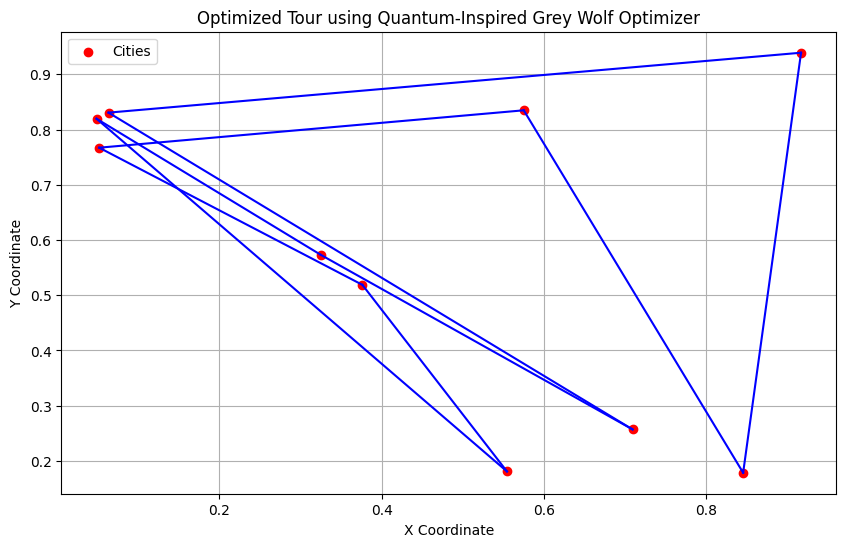

In [ ]:
import numpy as np
import pylatexenc
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator, Aer


# Define the coordinates
x = [0.554269387, 0.376125156, 0.051884288, 0.04856034, 0.574909957,
     0.845223483, 0.916561361, 0.063353565, 0.70899005, 0.324740555]

y = [0.180978238, 0.518855489, 0.767196762, 0.819692827, 0.834901769,
     0.178691015, 0.939163958, 0.830678509, 0.257090618, 0.573308569]

n_cities = len(x)
max_iterations = 100
population_size = 50

# Function to calculate the total distance of a tour
def calculate_distance(tour):
    distance = 0.0
    for i in range(len(tour) - 1):
        distance += np.sqrt((x[tour[i]] - x[tour[i + 1]]) ** 2 + (y[tour[i]] - y[tour[i + 1]]) ** 2)
    distance += np.sqrt((x[tour[-1]] - x[tour[0]]) ** 2 + (y[tour[-1]] - y[tour[0]]) ** 2)  # Return to start
    return distance

# Quantum-Inspired Grey Wolf Optimizer
class QIGWO:
    def __init__(self, population_size, max_iterations):
        self.population_size = population_size
        self.max_iterations = max_iterations
        self.wolves = [np.random.permutation(n_cities) for _ in range(population_size)]
        self.alpha = self.wolves[0]  # Initialize alpha to the first wolf
        self.beta = None
        self.delta = None
        self.alpha_score = float('inf')
        self.beta_score = float('inf')
        self.delta_score = float('inf')

    def optimize(self):
        for iteration in range(self.max_iterations):
            for wolf in self.wolves:
                score = self.quantum_evaluation(wolf)  # Use quantum evaluation for fitness
                self.update_leaders(wolf, score)

            a = 2 - iteration * (2 / self.max_iterations)  # Decrease a from 2 to 0

            for i in range(self.population_size):
                self.update_wolf_position(i, a)

        return self.alpha, self.alpha_score

    def update_leaders(self, wolf, score):
        if score < self.alpha_score:
            self.delta_score = self.beta_score
            self.delta = self.beta.copy() if self.beta is not None else None
            self.beta_score = self.alpha_score
            self.beta = self.alpha.copy() if self.alpha is not None else None
            self.alpha_score = score
            self.alpha = wolf.copy()
        elif score < self.beta_score:
            self.delta_score = self.beta_score
            self.delta = self.beta.copy() if self.beta is not None else None
            self.beta_score = score
            self.beta = wolf.copy()
        elif score < self.delta_score:
            self.delta_score = score
            self.delta = wolf.copy()

    def update_wolf_position(self, index, a):
        # Update positions based on alpha, beta, delta
        for j in range(len(self.wolves[index])):
            r1 = np.random.rand()
            r2 = np.random.rand()
            A = 2 * a * r1 - a
            C = 2 * r2
            D_alpha = np.abs(C * self.alpha[j] - self.wolves[index][j])
            X1 = self.alpha[j] - A * D_alpha

            r1 = np.random.rand()
            A = 2 * a * r1 - a
            D_beta = np.abs(C * self.beta[j] - self.wolves[index][j])
            X2 = self.beta[j] - A * D_beta

            r1 = np.random.rand()
            A = 2 * a * r1 - a
            D_delta = np.abs(C * self.delta[j] - self.wolves[index][j])
            X3 = self.delta[j] - A * D_delta

            # Update the wolf's position
            self.wolves[index][j] = (X1 + X2 + X3) / 3

        # Ensure valid permutation
        self.wolves[index] = self.ensure_valid_permutation(self.wolves[index])

    def ensure_valid_permutation(self, wolf):
        # Round and convert to integers
        wolf = np.round(wolf).astype(int) % n_cities  # Ensure indices are within bounds
        unique_cities = np.unique(wolf)
        if len(unique_cities) < n_cities:
            missing_cities = np.setdiff1d(np.arange(n_cities), unique_cities)
            wolf = np.concatenate((unique_cities, np.random.choice(missing_cities, n_cities - len(unique_cities), replace=False)))
        return wolf[:n_cities]  # Ensure the length is exactly n_cities

    def quantum_evaluation(self, wolf):
        # Create a quantum circuit for evaluating the fitness of a wolf
        circuit = QuantumCircuit(len(wolf))
        for i in range(len(wolf)):
            circuit.h(i)  # Apply Hadamard gate for superposition

        # Measure the circuit
        circuit.measure_all()

        # Visualize the quantum circuit
        #print(circuit.draw(output='text'))  # Print the circuit in text format
        #circuit.draw(output='mpl', filename='quantum_circuit.png')  # Save the circuit as an image

        # Execute the circuit using the Aer simulator
        backend = Aer.get_backend('aer_simulator')
        job = backend.run(circuit, shots=1024)  # Use the run method
        result = job.result()
        counts = result.get_counts(circuit)

        # Process the results to evaluate the fitness
        fitness = self.calculate_fitness_from_counts(counts)
        return fitness

    def calculate_fitness_from_counts(self, counts):
        # Convert quantum counts to a fitness value
        total_counts = sum(counts.values())
        fitness = 0.0

        for outcome, count in counts.items():
            # Convert outcome to a tour (assuming outcome is a binary string)
            tour = [int(i) for i in outcome]  # Convert to list of integers
            cost = calculate_distance(tour)  # Calculate the cost of the tour

            # Example logic: fitness is inversely proportional to the cost
            probability = count / total_counts  # Normalize the count
            fitness += probability * (1 / (1 + cost))  # Higher fitness for lower cost

        return fitness

# Plotting function
def plot_tour(tour, title):
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color='red', label='Cities')
    for i in range(len(tour)):
        plt.plot([x[tour[i]], x[tour[(i + 1) % len(tour)]]], [y[tour[i]], y[tour[(i + 1) % len(tour)]]], color='blue')
    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.legend()
    plt.grid()
    plt.show()

# Main execution
if __name__ == "__main__":
    qigwo = QIGWO(population_size, max_iterations)
    best_tour, best_distance = qigwo.optimize()

    print("Best Tour:", best_tour)
    print("Best Distance:", best_distance)

    # Plot the optimized tour
    plot_tour(best_tour, "Optimized Tour using Quantum-Inspired Grey Wolf Optimizer")

In [ ]:
import numpy as np
import pylatexenc
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator, Aer


# Define the coordinates
x = [0.554269387, 0.376125156, 0.051884288, 0.04856034, 0.574909957,
     0.845223483, 0.916561361, 0.063353565, 0.70899005, 0.324740555]

y = [0.180978238, 0.518855489, 0.767196762, 0.819692827, 0.834901769,
     0.178691015, 0.939163958, 0.830678509, 0.257090618, 0.573308569]

n_cities = len(x)
max_iterations = 100
population_size = 50

# Function to calculate the total distance of a tour
def calculate_distance(tour):
    distance = 0.0
    for i in range(len(tour) - 1):
        distance += np.sqrt((x[tour[i]] - x[tour[i + 1]]) ** 2 + (y[tour[i]] - y[tour[i + 1]]) ** 2)
    distance += np.sqrt((x[tour[-1]] - x[tour[0]]) ** 2 + (y[tour[-1]] - y[tour[0]]) ** 2)  # Return to start
    return distance

# Quantum-Inspired Grey Wolf Optimizer
class QIGWO:
    def __init__(self, population_size, max_iterations):
        self.population_size = population_size
        self.max_iterations = max_iterations
        self.wolves = [np.random.permutation(n_cities) for _ in range(population_size)]
        self.alpha = self.wolves[0]  # Initialize alpha to the first wolf
        self.beta = None
        self.delta = None
        self.alpha_score = float('inf')
        self.beta_score = float('inf')
        self.delta_score = float('inf')

    def optimize(self):
        for iteration in range(self.max_iterations):
            for wolf in self.wolves:
                score = self.quantum_evaluation(wolf)  # Use quantum evaluation for fitness
                self.update_leaders(wolf, score)

            a = 2 - iteration * (2 / self.max_iterations)  # Decrease a from 2 to 0

            for i in range(self.population_size):
                self.update_wolf_position(i, a)

        return self.alpha, self.alpha_score

    def update_leaders(self, wolf, score):
        if score < self.alpha_score:
            self.delta_score = self.beta_score
            self.delta = self.beta.copy() if self.beta is not None else None
            self.beta_score = self.alpha_score
            self.beta = self.alpha.copy() if self.alpha is not None else None
            self.alpha_score = score
            self.alpha = wolf.copy()
        elif score < self.beta_score:
            self.delta_score = self.beta_score
            self.delta = self.beta.copy() if self.beta is not None else None
            self.beta_score = score
            self.beta = wolf.copy()
        elif score < self.delta_score:
            self.delta_score = score
            self.delta = wolf.copy()

    def update_wolf_position(self, index, a):
        # Update positions based on alpha, beta, delta
        for j in range(len(self.wolves[index])):
            r1 = np.random.rand()
            r2 = np.random.rand()
            A = 2 * a * r1 - a
            C = 2 * r2
            D_alpha = np.abs(C * self.alpha[j] - self.wolves[index][j])
            X1 = self.alpha[j] - A * D_alpha

            r1 = np.random.rand()
            A = 2 * a * r1 - a
            D_beta = np.abs(C * self.beta[j] - self.wolves[index][j])
            X2 = self.beta[j] - A * D_beta

            r1 = np.random.rand()
            A = 2 * a * r1 - a
            D_delta = np.abs(C * self.delta[j] - self.wolves[index][j])
            X3 = self.delta[j] - A * D_delta

            # Update the wolf's position
            self.wolves[index][j] = (X1 + X2 + X3) / 3

        # Ensure valid permutation
        self.wolves[index] = self.ensure_valid_permutation(self.wolves[index])

    def ensure_valid_permutation(self, wolf):
        # Round and convert to integers
        wolf = np.round(wolf).astype(int) % n_cities  # Ensure indices are within bounds
        unique_cities = np.unique(wolf)
        if len(unique_cities) < n_cities:
            missing_cities = np.setdiff1d(np.arange(n_cities), unique_cities)
            wolf = np.concatenate((unique_cities, np.random.choice(missing_cities, n_cities - len(unique_cities), replace=False)))
        return wolf[:n_cities]  # Ensure the length is exactly n_cities

    def quantum_evaluation(self, wolf):
    # Create a quantum circuit for evaluating the fitness of a wolf
      circuit = QuantumCircuit(len(wolf))

    # Encode the wolf's tour into the quantum circuit
      for i in range(len(wolf)):
        # Apply a Hadamard gate for superposition
        circuit.h(i)
        # Encode the city index as a phase rotation
        circuit.rz(2 * np.pi * wolf[i] / n_cities, i)

    # Apply entanglement (optional, depending on your approach)
      for i in range(len(wolf) - 1):
        circuit.cx(i, i + 1)  # Controlled-X gate

    # Measure the circuit
      circuit.measure_all()

    #Visualize the quantum circuit
      print(circuit.draw(output='text'))  # Print the circuit in text format
      circuit.draw(output='mpl', filename='quantum_circuit.png')  # Save the circuit as an image


    # Execute the circuit using the Aer simulator
      backend = Aer.get_backend('aer_simulator')
      job = backend.run(circuit, shots=1024)  # Use the run method
      result = job.result()
      counts = result.get_counts(circuit)

    # Process the results to evaluate the fitness
      fitness = self.calculate_fitness_from_counts(counts, wolf)
      return fitness

    def calculate_fitness_from_counts(self, counts, wolf):
    # Convert quantum counts to a fitness value
      total_counts = sum(counts.values())
      fitness = 0.0

      for outcome, count in counts.items():
        # Convert outcome to a tour (assuming outcome is a binary string)
        # Here we need to decode the outcome based on the length of the wolf
        binary_string = outcome.zfill(len(wolf) * 4)  # Ensure the binary string is padded to the correct length
        tour = [int(binary_string[i:i + 4], 2) % n_cities for i in range(0, len(binary_string), 4)]

        # Calculate the cost of the tour
        cost = calculate_distance(tour)  # Calculate the cost of the tour

        # Example logic: fitness is inversely proportional to the cost
        probability = count / total_counts  # Normalize the count
        fitness += probability * (1 / (1 + cost))  # Higher fitness for lower cost

      return fitness

# Plotting function
def plot_tour(tour, title):
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color='red', label='Cities')
    for i in range(len(tour)):
        plt.plot([x[tour[i]], x[tour[(i + 1) % len(tour)]]], [y[tour[i]], y[tour[(i + 1) % len(tour)]]], color='blue')
    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.legend()
    plt.grid()
    plt.show()

# Main execution
if __name__ == "__main__":
    qigwo = QIGWO(population_size, max_iterations)
    best_tour, best_distance = qigwo.optimize()

    print("Best Tour:", best_tour)
    print("Best Distance:", best_distance)

    # Plot the optimized tour
    plot_tour(best_tour, "Optimized Tour using Quantum-Inspired Grey Wolf Optimizer")

Streaming output truncated to the last 5000 lines.
         ├───┤├──────────┤                         └───┘┌─┴─┐           ░  ║ »
    q_7: ┤ H ├┤ Rz(7π/5) ├──────────────────────────────┤ X ├──■────────░──╫─»
         ├───┤├──────────┤                              └───┘┌─┴─┐      ░  ║ »
    q_8: ┤ H ├┤ Rz(4π/5) ├───────────────────────────────────┤ X ├──■───░──╫─»
         ├───┤└┬───────┬─┘                                   └───┘┌─┴─┐ ░  ║ »
    q_9: ┤ H ├─┤ Rz(π) ├──────────────────────────────────────────┤ X ├─░──╫─»
         └───┘ └───────┘                                          └───┘ ░  ║ »
meas: 10/══════════════════════════════════════════════════════════════════╩═»
                                                                           0 »
«                                    
«    q_0: ───────────────────────────
«         ┌─┐                        
«    q_1: ┤M├────────────────────────
«         └╥┘┌─┐                     
«    q_2: ─╫─┤M├─────────────────────
«         